# Exploring High-Impact Rainfall from Hurricane Ida's Remnants with MPAS-Viewer (Part 2)

## Overview

This notebook is a continuation of the notebook "Exploring High-Impact Rainfall from Hurricane Ida’s Remnants with MPAS-Viewer". Here, we're exploring how to create a spatial plot the temperature field, as well as selecting a single point to visualize different variables.

## Imports

In [158]:
from mpasviewer import scvtmesh
import cartopy.crs as ccrs
from datetime import datetime

from earthcmap import escmap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import cartopy.feature as cfeature

## Data retrieval

In [17]:
url_thredds = "https://thredds.hydroshare.org/thredds/catalog/hydroshare/resources/6be754bf29cb488b815810c35f3f0ac9/data/contents/nyc_out/catalog.html" ### New York
inidt = datetime(2021, 9, 1, 13); enddt = datetime(2021, 9, 2, 12) ## NYC

list_files = scvtmesh.get_thredds_list(url_thredds)#, date_start=inidt, date_end=enddt)

In [18]:
mpasd = scvtmesh(grid_file='http://thredds.hydroshare.org/thredds/dodsC/hydroshare/resources/6be754bf29cb488b815810c35f3f0ac9/data/contents/nyc_static/nyc.static.nc',
                 diag_list=list_files)

## Loading variables

In [19]:
mpasd.dataset(load_variables=['rainnc', 'rainc', 'precipw', 't2m', 'uzonal'])

Loaded grid_file dataset: http://thredds.hydroshare.org/thredds/dodsC/hydroshare/resources/6be754bf29cb488b815810c35f3f0ac9/data/contents/nyc_static/nyc.static.nc


In [20]:
mpasd.rain_rate()

## Loading our data

In [21]:
dta = mpasd.load()

In [22]:
dta

<xarray.Dataset> Size: 82MB
Dimensions:                      (node: 56386, edge: 84247, face: 27862,
                                  time: 48, nPresLevels: 8, nmax_face: 6)
Coordinates:
    node_x                       (node) float32 226kB -74.89 -74.87 ... -75.29
    node_y                       (node) float32 226kB 41.36 41.38 ... 38.98
    edge_x                       (edge) float32 337kB -74.89 -74.9 ... -75.3
    edge_y                       (edge) float32 337kB 41.36 41.35 ... 38.97
    face_x                       (face) float32 111kB -74.87 -74.89 ... -75.33
    face_y                       (face) float32 111kB 41.36 41.34 ... 38.96
  * time                         (time) datetime64[ns] 384B 2021-09-01 ... 20...
  * nPresLevels                  (nPresLevels) int64 64B 925 850 700 ... 100 50
Dimensions without coordinates: node, edge, face, nmax_face
Data variables:
    mesh2d                       int32 4B 0
    projected_coordinate_system  int32 4B 0
    face_nodes                   (face, nmax_face) int32 669kB 0 125 ... 56383
    rainnc                       (time, face) float32 5MB dask.array<chunksize=(1, 27862), meta=np.ndarray>
    rainc                        (time, face) float32 5MB dask.array<chunksize=(1, 27862), meta=np.ndarray>
    precipw                      (time, face) float32 5MB dask.array<chunksize=(1, 27862), meta=np.ndarray>
    t2m                          (time, face) float32 5MB dask.array<chunksize=(1, 27862), meta=np.ndarray>
    uzonal                       (time, nPresLevels, face) float32 43MB dask.array<chunksize=(1, 1, 27862), meta=np.ndarray>
    rainnc_rate                  (time, face) float32 5MB 0.0 0.0 ... 0.0 0.0
    rainc_rate                   (time, face) float32 5MB dask.array<chunksize=(1, 27862), meta=np.ndarray>
    rain_rate                    (time, face) float32 5MB dask.array<chunksize=(1, 27862), meta=np.ndarray>
Attributes:
    Conventions:      CF-1.12 UGRID-1.0
    model_name:       MPAS
    core_name:        Atmosphere
    source:           MPAS-A
    source_software:  MPAS-viewer
    date_created:     2026-06-18 16:00:01Z
    date_modified:    2026-06-18 16:00:01Z

In [23]:
times = [str(x) for x in dta['time'].data.astype('datetime64[s]')]

## Visualizing temperature data and creating a gif

Given that we're going to plot temperatures, we will first define the colorbar and units we're going to use.

In [95]:
cmap, norm = escmap("temp_ecmwf", units="K")

In [92]:
for idx in range(len(dta.time)):

    mpasd.show(
        dta,
        var_name="t2m",
        time_index=idx,
        figsize=(5, 5),
        cmap=cmap,
        norm=norm,
    )

    # Add timestamp to each frame
    timestamp = pd.to_datetime(dta.time.values[idx])
    timestr = timestamp.strftime("%d %b %Y, %H:%M UTC")

    plt.title(
        f"{timestr}",
        pad=40,
        x=0.61
    )

    plt.savefig(
        f"temperature{idx:02d}.png",
        dpi=150,
        bbox_inches="tight"
    )

    plt.close()

Now, we make use of the image module under the Python Imaging Library, and retrieve all the figures we created in our previous step:

In [93]:
from PIL import Image

files = [f"temperature{i:02d}.png" for i in range(len(dta.time))]

frames = [Image.open(f).convert("RGB") for f in files]

frames[0].save(
    "Ida_Temperature_Evolution.gif",
    save_all=True,
    append_images=frames[1:],
    duration=500,
    loop=0
)

Lastly, we go ahead and create our animated image!

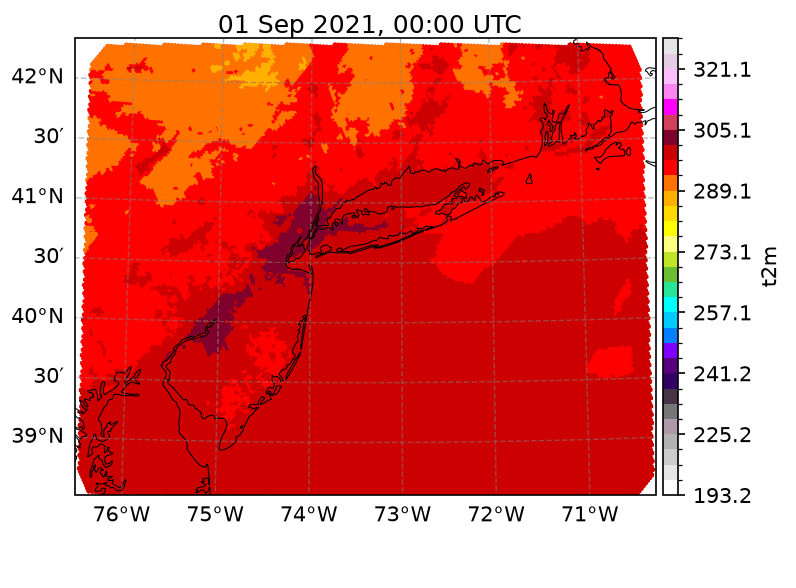

In [94]:
from IPython.display import Image as IPImage

IPImage(filename="Ida_Temperature_Evolution.gif")

Figure 1. Two-meter temperature variation from 01 September 2021 00:00 UTC to 02 September 2021 23:00 UTC, with 1 hour step progressions. 

## Exploring other variables at a set location

Oftentimes, researchers need to compare modelled data with observational data (or data from other sources) for their studies. Therefore, it is important to know how to select a point within an MPAS-A output. 

>**Remember:** MPAS-A utilizes an unstructured Voronoi mesh. For mapping information of a specific point (given its latitude and longitude), a cellid can be used. Cellid's are a unique index number for each of the hexagonal cells that compose the MPAS gridded structure.

The point we want to analyze can be seen through this map:

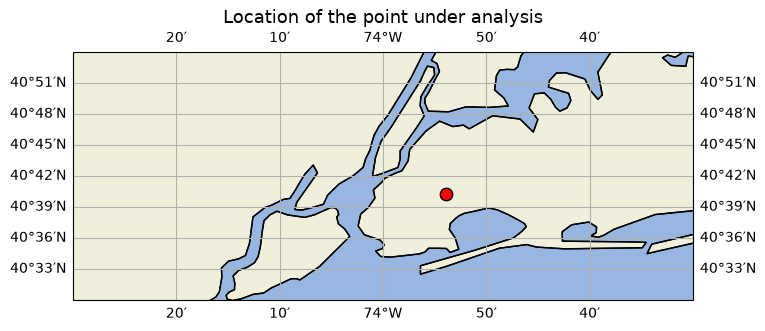

In [163]:
fig = plt.figure(figsize=(8, 8))
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))

#Add coastlines and land
for features in [cfeature.COASTLINE, cfeature.LAND, cfeature.BORDERS, cfeature.STATES, cfeature.OCEAN]:
    ax.add_feature(features)

ax.set_extent([285.5, 286.5, 40.5, 40.9], crs=ccrs.PlateCarree())

station_lon = -73.898
station_lat = 40.672

ax.scatter(station_lon, station_lat, s=80, color='red', edgecolor='black', zorder=5, transform=ccrs.PlateCarree())

ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
ax.gridlines(draw_labels=True, xlocs=np.arange(-180,210,15), ylocs=np.arange(-180,180,5))
ax.tick_params(axis='both', which='major', labelsize=50)

plt.title('Location of the point under analysis', fontsize=13)
plt.show()

Figure 2. Spatial location of the point under analysis.

We now identify the cellid that's linked to the longitude and latitude we want to analyze by using the mpasviewer function **latlon2cellid**:

In [34]:
cellid = mpasd.latlon2cellid(lon = -73.898, lat = 40.672)
print(cellid)

23160


### Rain rate time series

Now that our cell has been identified, we go ahead and retrieve rain rate data for that specific cell:

In [35]:
pt0 = dta['rain_rate'].sel(face = cellid)

And now, we can now plot the rain rate for our specific cell!

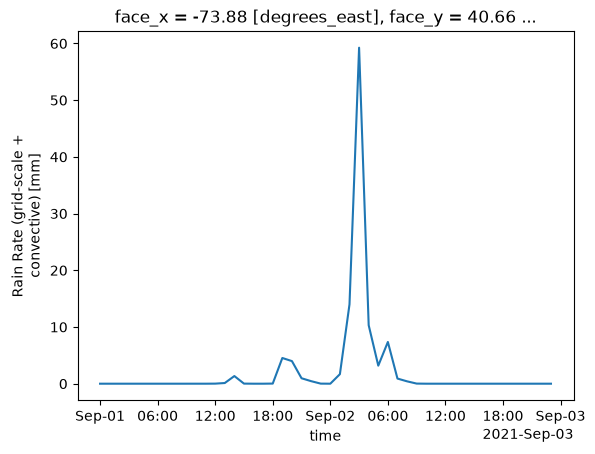

In [102]:
pt0.plot()

Figure 3. Temporal distribution of rain rate for the selected location. On 01 September, two relatively small increments in rain rates can be observed, while a considerable peak is detected on 02 September, with a value nearing the 60 mm mark. 

### Temperature time series

The same logic can be applied for any other variable that we want to analyze. Here, we will look at the variation in temperatures through time for our specific location:

In [38]:
pt1 = dta['t2m'].sel(face = cellid)

Text(0.5, 1.0, '2m Temperature (t2m)')

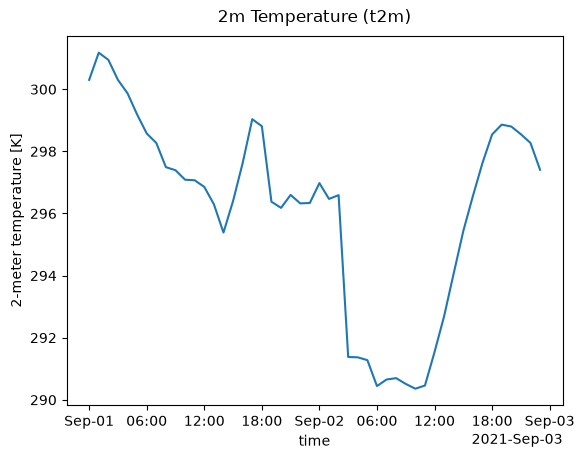

In [117]:
pt1.plot()
plt.title("2m Temperature (t2m)", pad=10)

Figure 4. Temporal distribution of the 2-meter temperature for the selected location. A considerably large decrease in temperatures is observed on 02 September 04:00 UTC, time at which the largest rain rate (Fig. 3) was observed.

### Vertical wind profile

From our dataset, we can also obtain the vertical distribution of zonal winds for our selected location. Here, we first isolate our variable **uzonal** for our specific cellid:

In [24]:
profile = dta['uzonal'].sel(face = cellid)#.to_dataframe()

We can now set our y axis as the pressue levels to obtain a vertical profile:

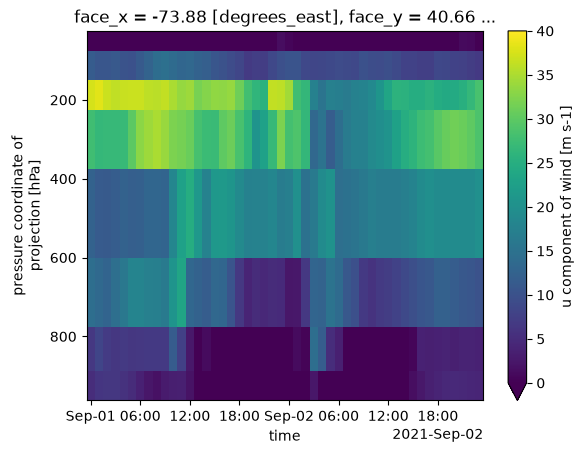

In [25]:
profile.plot(y = 'nPresLevels', yincrease = False, vmin = 0, vmax = 40)

Figure 5. Time series of the zonal component of the wind for different pressure levels.

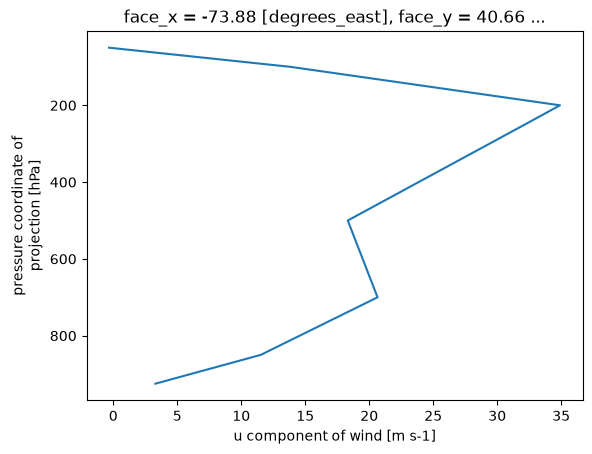

In [26]:
profile[10,:].plot(y = 'nPresLevels', yincrease = False)

Figure 

In [177]:
profile[10,:]

<xarray.DataArray 'uzonal' (nPresLevels: 8)> Size: 32B
dask.array<getitem, shape=(8,), dtype=float32, chunksize=(1,), chunktype=numpy.ndarray>
Coordinates:
    face_x       float32 4B -73.88
    face_y       float32 4B 40.66
    time         datetime64[ns] 8B 2021-09-01T10:00:00
  * nPresLevels  (nPresLevels) int64 64B 925 850 700 500 250 200 100 50
Attributes:
    mesh:           mesh2d
    location:       face
    long_name:      u component of wind
    standard_name:  u_component
    units:          m s-1
    positive:       east
    var_name:       uzonal
    grid_mapping:   projected_coordinate_system